### All Imports and Libraries

In [1]:
import os
import sys
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.poisson_ci_detector import ImprovedPoissonConcentrationML
from src.features import (
    infer_protocol_column,
    compute_jitter_iat_features,
    compute_source_flow_concentration,
    generate_concentration_weighted_ci
)
from src.evaluation import (
    poisson_diagnostic,
    eval_baseline,
    compute_delay,
    combined_stream_metrics
)
from src.baselines import (
    ThreeSigmaBaseline,
    LayeredSigmaBaseline,
    MADZBaseline,
    IsolationForestBaseline,
    OneClassSVMBaseline,
    LSTMAutoencoderBaseline,
    TransformerAutoencoderBaseline
)

import numpy as np
import time as time_module
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore", message="Overdispersion detected in >25% of features.")

# PHASE 1a IMPLEMENTATION

### Load and Inspect Benign

In [2]:
# ============================================================
# STEP 1: LOAD BENIGN DATA
# ============================================================

BASE_PATH = "../data"

benign_path = os.path.join(BASE_PATH, "BenignTraffic1.csv")
df_benign = pd.read_csv(benign_path, low_memory=False)

# ------------------------------------------------------------
# FIXED TIMESTAMP COLUMN (based on prior validation)
# ------------------------------------------------------------
timestamp_col = "time_since_previously_displayed_frame"

# Fallback (if needed for portability)
if timestamp_col not in df_benign.columns:
    timestamp_col = "inter_arrival_time"

if timestamp_col not in df_benign.columns:
    raise ValueError("No valid timestamp column found in dataset.")

### Timestamp Reconstruction and Label Assignment

In [3]:
# ============================================================
# STEP 2: TIMESTAMP RECONSTRUCTION + LABEL ASSIGNMENT (10 ms bins)
# ============================================================

# -- Sort and clean time deltas
df_benign = df_benign.sort_index().copy()

df_benign[timestamp_col] = (
    df_benign[timestamp_col]
    .clip(lower=0)
    .fillna(0)
)

# -- Reconstruct timeline
start_time = pd.Timestamp("2024-01-01 00:00:00")

df_benign["time_elapsed_s"] = df_benign[timestamp_col].cumsum()

df_benign["Timestamp_parsed"] = start_time + pd.to_timedelta(
    df_benign["time_elapsed_s"], unit="s"
)

# -- Label assignment
df_benign["Label"] = 0

# -- Bin timestamps into 10 ms intervals
df_benign["time_bin_10ms"] = df_benign["Timestamp_parsed"].dt.floor("10ms")

## Aggregation by 10 ms bins and VMR Diagnostics

In [4]:
# ============================================================
# STEP 3: AGGREGATION (10 ms bins)
# ============================================================

# Infer protocol
df_benign = infer_protocol_column(df_benign)

# Prepare numeric columns safely
for col in ["Total Length of Fwd Packet", "Total Length of Bwd Packet", "Flow Duration", "SYN Flag Count"]:
    if col not in df_benign.columns:
        df_benign[col] = 0

df_benign["total_bytes"] = (
    df_benign["Total Length of Fwd Packet"] +
    df_benign["Total Length of Bwd Packet"]
)

df_benign["flow_duration"] = df_benign["Flow Duration"]
df_benign["syn_flag"] = df_benign["SYN Flag Count"]

# Aggregations per 10 ms bin
agg_df_10ms = (
    df_benign.groupby("time_bin_10ms").agg(
        event_count=("Protocol", "size"),
        TCP=("Protocol", lambda x: np.sum(x == "TCP")),
        UDP=("Protocol", lambda x: np.sum(x == "UDP")),
        ICMP=("Protocol", lambda x: np.sum(x == "ICMP")),
        OTHER=("Protocol", lambda x: np.sum(x == "OTHER")),
        total_bytes_sum=("total_bytes", "sum"),
        avg_flow_dur=("flow_duration", "mean"),
        syn_flag_sum=("syn_flag", "sum")
    ).reset_index()
)

# Final cleanup
agg_df_10ms = (
    agg_df_10ms
    .fillna(0)
    .sort_values("time_bin_10ms")
    .reset_index(drop=True)
)

### Native IAT / Jitter Micro-feature Integration

In [5]:
# ============================================================
# STEP 4: IAT / JITTER FEATURE INTEGRATION (BENIGN)
# ============================================================

agg_df_10ms = compute_jitter_iat_features(df_benign, agg_df_10ms)

# Ensure required column exists
if "time_bin_10ms" not in agg_df_10ms.columns:
    raise ValueError("time_bin_10ms column missing after jitter feature computation.")

### VMR Diagnostic (10 ms Bins)

In [6]:
# ============================================================
# STEP 5: POISSON VMR DIAGNOSTIC (BENIGN)
# ============================================================

poisson_results_benign_10ms = poisson_diagnostic(
    agg_df_10ms,
    label="Benign (10 ms bins)",
    verbose=True
)


=== Poisson Behaviour Diagnostic — Benign (10 ms bins) ===
        Feature  Mean Variance   VMR          Status
    event_count 2.424    8.601 3.549  Over-dispersed
      iat_count 2.424    8.601 3.549  Over-dispersed
            TCP 1.985    9.062 4.565  Over-dispersed
            UDP 0.332    0.399 1.201  Over-dispersed
           ICMP 0.016    0.016 0.997       ≈ Poisson
          OTHER 0.091    0.096 1.054       ≈ Poisson
total_bytes_sum 0.000    0.000 0.000 Under-dispersed
   avg_flow_dur 0.000    0.000 0.000 Under-dispersed
   syn_flag_sum 0.000    0.000 0.000 Under-dispersed

[SUMMARY]
  Over-dispersed : 4 features
  Under-dispersed: 3 features
  ≈ Poisson      : 2 features

[AVERAGE VMR] 1.657


### Temporal Dispersion Integration Feature Integration

In [7]:
# ============================================================
# STEP 6: TEMPORAL-DISPERSION FEATURE INTEGRATION
# ============================================================

df_disp = agg_df_10ms.copy().sort_values("time_bin_10ms").reset_index(drop=True)

# Ensure time continuity
df_disp["time_bin_10ms"] = pd.to_datetime(df_disp["time_bin_10ms"])
df_disp = df_disp.set_index("time_bin_10ms")

# Core signal for λ and dispersion estimation
core_col = "event_count"

# Rolling λ (expected count per bin)
df_disp["rolling_lambda"] = (
    df_disp[core_col]
    .rolling(window=50, min_periods=1)
    .mean()
)

# Rolling dispersion index
roll_mean = df_disp[core_col].rolling(window=20, min_periods=1).mean()
roll_var  = df_disp[core_col].rolling(window=20, min_periods=1).var()

df_disp["rolling_dispersion"] = np.where(
    roll_mean > 0,
    roll_var / roll_mean,
    0
)

# Log transforms
df_disp["log_lambda"] = np.log1p(df_disp["rolling_lambda"])
df_disp["log_dispersion"] = np.log1p(df_disp["rolling_dispersion"])

# Final cleanup
df_disp = df_disp.fillna(0).reset_index()

### Jitter Feature Integration (Benign)

In [8]:
# ============================================================
# STEP 7: JITTER FEATURE INTEGRATION (BENIGN)
# ============================================================

# Ensure required column exists
if "event_count" not in df_disp.columns:
    raise ValueError("event_count column missing before jitter computation.")

# Absolute change in event_count between consecutive bins
df_disp["jitter_abs"] = df_disp["event_count"].diff().abs().fillna(0)

# Log-transform for numerical stability
df_disp["log_jitter"] = np.log1p(df_disp["jitter_abs"])

### Feature Preparation

In [9]:
# ============================================================
# STEP 8: FEATURE MATRIX PREPARATION + SCALING
# ============================================================

# Feature selection
feature_cols = [
    "event_count", "TCP", "UDP", "ICMP", "OTHER",
    "syn_flag_sum", "total_bytes_sum",
    "log_lambda", "log_dispersion", "jitter_abs", "log_jitter",
    "log_iat_mean", "log_iat_std", "log_iat_cv", "log_iat_madd"
]

feature_cols = [c for c in feature_cols if c in df_disp.columns]

if len(feature_cols) == 0:
    raise ValueError("No valid features found for model training.")

# Target variable
target_col = "event_count"

# ============================================================
# Selective Feature Re-Scaling (low-variance features)
# ============================================================

minor_cols = [c for c in ["TCP", "UDP", "ICMP", "OTHER", "syn_flag_sum"] if c in df_disp.columns]

if minor_cols:
    scaler_minor = RobustScaler()
    df_disp[minor_cols] = scaler_minor.fit_transform(df_disp[minor_cols])

# ============================================================
# Build feature matrix and scale
# ============================================================

X_all = df_disp[feature_cols].fillna(0).astype(float).values
y_all = df_disp[target_col].astype(float).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

### Benign Train - Validation Split (10 ms)

In [10]:
# ============================================================
# STEP 9: TRAIN / VALIDATION SPLIT (CHRONOLOGICAL)
# ============================================================

n = len(X_scaled)
split_idx = int(n * 0.8)

X_train, X_val = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_val = y_all[:split_idx], y_all[split_idx:]

### Train & Validate Poisson Model (Benign 10 MS)

In [11]:
# ============================================================
# STEP 10: TRAIN & VALIDATE POISSON MODEL (BENIGN)
# ============================================================

model = ImprovedPoissonConcentrationML(
    model_type="linear",
    q=2,
    confidence_level=0.95,
    lambda_mode="model_based",
    use_conditional=False,
    local_lambda_estimation=True,
    empirical_calibration=True,
    verbose=False
)

model.safe_fit(X_train, y_train)

# Save benign λ for reuse
lambda_benign = model.lambda_estimates.copy()

# Validate on benign hold-out
preds_val, ci_val = model.predict_with_confidence(X_val)

lower_val, upper_val = ci_val[:, 0], ci_val[:, 1]
observed_val = y_val

# Ensure valid intervals
inverted = lower_val > upper_val
if np.any(inverted):
    raise ValueError(f"Inverted confidence intervals detected: {np.sum(inverted)} cases.")

# Metrics
fp = np.sum((observed_val < lower_val) | (observed_val > upper_val))
tn = len(observed_val) - fp
fp_rate = fp / len(observed_val)

mean_width = np.mean(upper_val - lower_val)
coverage = 1 - fp_rate

print(f"\n[VALIDATION] Benign Validation Results:")
print(f"  False Positives (FP): {fp:,}")
print(f"  True Negatives (TN):  {tn:,}")
print(f"  FP Rate: {fp_rate:.4f}  |  Coverage: {coverage:.4f}")
print(f"  Mean CI Width: {mean_width:.4f}")

validation_summary = {
    "False Positives": fp,
    "True Negatives": tn,
    "FP Rate": fp_rate,
    "Coverage": coverage,
    "Mean CI Width": mean_width
}


[VALIDATION] Benign Validation Results:
  False Positives (FP): 5
  True Negatives (TN):  24,355
  FP Rate: 0.0002  |  Coverage: 0.9998
  Mean CI Width: 1.1039


# PHASE 1(b) Implementation

### Load and Inspect Attack File

In [12]:
# ============================================================
# LOOP CONFIGURATION
# ============================================================

BASE_PATH = "../data"

ATTACK_FILES = {
    "DoS-TCP": os.path.join(BASE_PATH, "DoS-TCP_Flood.csv"),
    "DoS-UDP": os.path.join(BASE_PATH, "DoS-UDP_Flood.csv"),
    "DDoS-TCP": os.path.join(BASE_PATH, "DDoS-TCP_Flood.csv"),
    "DDoS-ICMP": os.path.join(BASE_PATH, "DDoS-ICMP_Fragmentation.csv"),
    "Mirai": os.path.join(BASE_PATH, "Mirai-greip_flood.csv"),
    "Recon": os.path.join(BASE_PATH, "VulnerabilityScan.csv"),
    "WebBased": os.path.join(BASE_PATH, "SqlInjection.csv"),
    "BruteForce": os.path.join(BASE_PATH, "DictionaryBruteForce.csv"),
}

In [13]:
def run_attack_pipeline(attack_name, attack_path):

    # ------------------------------------------------------------
    # Load Attack CSV
    # ------------------------------------------------------------
    if not os.path.exists(attack_path):
        print(f"[SKIP] File not found: {attack_path}")
        return None

    df_atk = pd.read_csv(attack_path, low_memory=False)

    # Clean name
    attack_name = attack_name.replace("_pcap_Flow", "").replace("_Flow", "").replace("_", "-")


    # ============================================================
    # STEP B: TIMESTAMP RECONSTRUCTION
    # ============================================================
    df_atk = df_atk.sort_index().copy()

    if timestamp_col not in df_atk.columns:
        raise ValueError(f"{timestamp_col} not found in attack dataset.")

    df_atk[timestamp_col] = (
        df_atk[timestamp_col]
        .clip(lower=0)
        .fillna(0)
    )

    start_time = pd.Timestamp("2024-01-01 00:00:00")

    df_atk["time_elapsed_s"] = df_atk[timestamp_col].cumsum()

    df_atk["Timestamp_parsed"] = start_time + pd.to_timedelta(
        df_atk["time_elapsed_s"], unit="s"
    )

    df_atk["Label"] = 1
    df_atk["time_bin_10ms"] = df_atk["Timestamp_parsed"].dt.floor("10ms")


    # ============================================================
    # STEP C: AGGREGATION
    # ============================================================

    df_atk = infer_protocol_column(df_atk)

    # Ensure numeric columns exist
    for col in [
        "Total Length of Fwd Packet",
        "Total Length of Bwd Packet",
        "Flow Duration",
        "SYN Flag Count"
    ]:
        if col not in df_atk.columns:
            df_atk[col] = 0

    df_atk["total_bytes"] = (
        df_atk["Total Length of Fwd Packet"] +
        df_atk["Total Length of Bwd Packet"]
    )

    df_atk["flow_duration"] = df_atk["Flow Duration"]
    df_atk["syn_flag"] = df_atk["SYN Flag Count"]

    agg_df_atk_10ms = (
        df_atk.groupby("time_bin_10ms").agg(
            event_count=("Protocol", "size"),
            TCP=("Protocol", lambda x: np.sum(x == "TCP")),
            UDP=("Protocol", lambda x: np.sum(x == "UDP")),
            ICMP=("Protocol", lambda x: np.sum(x == "ICMP")),
            OTHER=("Protocol", lambda x: np.sum(x == "OTHER")),
            total_bytes_sum=("total_bytes", "sum"),
            avg_flow_dur=("flow_duration", "mean"),
            syn_flag_sum=("syn_flag", "sum")
        ).reset_index()
    )

    agg_df_atk_10ms = (
        agg_df_atk_10ms
        .fillna(0)
        .sort_values("time_bin_10ms")
        .reset_index(drop=True)
    )

    print(f" Aggregated bins: {len(agg_df_atk_10ms)}")


    # ============================================================
    # STEP D: IAT / JITTER MICRO-FEATURES
    # ============================================================

    agg_df_atk_10ms = compute_jitter_iat_features(df_atk, agg_df_atk_10ms)

    # Ensure required column exists
    if "time_bin_10ms" not in agg_df_atk_10ms.columns:
        raise ValueError("time_bin_10ms column missing after jitter feature computation (attack).")


    # ============================================================
    # STEP E: POISSON DIAGNOSTIC
    # ============================================================

    poisson_results_attack_10ms = poisson_diagnostic(
        agg_df_atk_10ms,
        label=f"{attack_name} (10 ms bins)",
        verbose=False
    )


    # ============================================================
    # STEP F: TEMPORAL-DISPERSION FEATURES
    # ============================================================

    df_attack_disp = agg_df_atk_10ms.copy().sort_values("time_bin_10ms").reset_index(drop=True)

    # Ensure time continuity
    df_attack_disp["time_bin_10ms"] = pd.to_datetime(df_attack_disp["time_bin_10ms"])
    df_attack_disp = df_attack_disp.set_index("time_bin_10ms")

    # Core signal (must match benign)
    core_col = "event_count"

    # Rolling λ
    df_attack_disp["rolling_lambda"] = (
        df_attack_disp[core_col]
        .rolling(window=50, min_periods=1)
        .mean()
    )

    # Rolling dispersion
    roll_mean_a = df_attack_disp[core_col].rolling(window=20, min_periods=1).mean()
    roll_var_a  = df_attack_disp[core_col].rolling(window=20, min_periods=1).var()

    df_attack_disp["rolling_dispersion"] = np.where(
        roll_mean_a > 0,
        roll_var_a / roll_mean_a,
        0
    )

    # Log transforms
    df_attack_disp["log_lambda"] = np.log1p(df_attack_disp["rolling_lambda"])
    df_attack_disp["log_dispersion"] = np.log1p(df_attack_disp["rolling_dispersion"])

    # Final cleanup
    df_attack_disp = df_attack_disp.fillna(0).reset_index()


    # ============================================================
    # STEP G: JITTER FEATURES (MACRO)
    # ============================================================

    if "event_count" not in df_attack_disp.columns:
        raise ValueError("event_count column missing before attack jitter computation.")

    df_attack_disp["jitter_abs"] = df_attack_disp["event_count"].diff().abs().fillna(0)
    df_attack_disp["log_jitter"] = np.log1p(df_attack_disp["jitter_abs"])


    # ============================================================
    # STEP H: FEATURE MATRIX + SCALING
    # ============================================================

    # Feature list (must match benign)
    feature_cols = [
        "event_count", "TCP", "UDP", "ICMP", "OTHER",
        "syn_flag_sum", "total_bytes_sum",
        "log_lambda", "log_dispersion", "jitter_abs", "log_jitter",
        "log_iat_mean", "log_iat_std", "log_iat_cv", "log_iat_madd"
    ]

    feature_cols = [c for c in feature_cols if c in df_attack_disp.columns]

    if len(feature_cols) == 0:
        raise ValueError("No valid features found in attack dataset.")

    # Target
    target_col = "event_count"

    # Apply SAME RobustScaler (benign)
    minor_cols = [c for c in ["TCP", "UDP", "ICMP", "OTHER", "syn_flag_sum"] if c in df_attack_disp.columns]

    if "scaler" not in globals():
        raise ValueError("StandardScaler 'scaler' not found. Must reuse benign scaler.")

    if minor_cols and "scaler_minor" not in globals():
        raise ValueError("RobustScaler 'scaler_minor' not found. Must reuse benign scaler.")

    if minor_cols:
        df_attack_disp[minor_cols] = scaler_minor.transform(df_attack_disp[minor_cols])

    # Build matrix
    X_attack_all = df_attack_disp[feature_cols].fillna(0).astype(float).values
    y_attack_all = df_attack_disp[target_col].astype(float).values

    # Scale using benign scaler
    X_attack_scaled = scaler.transform(X_attack_all)

    
    # ============================================================
    # STEP I: ADAPTIVE DISPERSION WEIGHTING
    # ============================================================

    USE_ADAPTIVE_WEIGHTING = True  # keep for now (can move to config later)

    if USE_ADAPTIVE_WEIGHTING:

        lambda_vals = np.array(getattr(model, "lambda_estimates", []))

        if lambda_vals.size == 0:
            model.local_protocol_factor = 1.0
        else:
            low_intensity_mask = lambda_vals < 3
            low_ratio = np.mean(low_intensity_mask)

            if low_ratio > 0:
                model.local_protocol_factor = 0.5
            else:
                model.local_protocol_factor = 1.0
                

    # ============================================================
    # STEP I2: SOURCE / FLOW CONCENTRATION FEATURES
    # ============================================================

    USE_CONCENTRATION_FEATURES = True  # keep for now

    if USE_CONCENTRATION_FEATURES:

        agg_df_atk_10ms = compute_source_flow_concentration(
            raw_df=df_atk,
            agg_df=agg_df_atk_10ms,
            bin_col="time_bin_10ms",
            src_col="src_ip",   # ensure this exists in dataset
            flow_col=None
        )


    # ============================================================
    # STEP I3: DUAL FACTOR (ADAPTIVE PER-BIN SCALING)
    # ============================================================

    if "rolling_lambda" not in df_attack_disp.columns:
        raise ValueError("rolling_lambda missing for dual_factor computation.")

    lam_vals = df_attack_disp["rolling_lambda"].values

    dual_factor = np.ones_like(lam_vals, dtype=float)

    dual_factor[lam_vals < 3] = 0.75
    dual_factor[(lam_vals >= 3) & (lam_vals < 8)] = 0.85
    dual_factor[(lam_vals >= 8) & (lam_vals < 20)] = 0.95
    dual_factor[lam_vals >= 20] = 1.00

    dual_factor = np.clip(dual_factor, 0.5, 1.0)

    # Ensure alignment with feature matrix (FUNCTION-SAFE)
    if len(dual_factor) != len(X_attack_scaled):
        raise ValueError(
            f"dual_factor length ({len(dual_factor)}) does not match X_attack_scaled ({len(X_attack_scaled)})"
        )

    model.dual_factor = dual_factor


    # ============================================================
    # STEP I4: HIGH-INTENSITY MODE TOGGLE
    # ============================================================

    USE_HIGH_INTENSITY_MODE = True 

    high_intensity_threshold = 20.0
    high_fraction_threshold  = 0.02

    if USE_HIGH_INTENSITY_MODE:

        # Use df_attack_disp (function-safe, already has rolling_lambda)
        if "rolling_lambda" not in df_attack_disp.columns:
            # fallback (should rarely happen)
            rolling_lambda = (
                df_attack_disp["event_count"]
                .rolling(window=30, min_periods=1)
                .mean()
            )
        else:
            rolling_lambda = df_attack_disp["rolling_lambda"]

        # Compute high-intensity fraction
        high_bins_mask = rolling_lambda.fillna(0) >= float(high_intensity_threshold)
        high_bins_frac = float(np.mean(high_bins_mask))

        if high_bins_frac >= float(high_fraction_threshold):
            # Enable high-intensity mode: neutralize narrowing
            model.local_protocol_factor = 1.0

            if hasattr(model, "dual_factor"):
                try:
                    model.dual_factor = np.ones_like(model.dual_factor, dtype=float)
                except Exception:
                    model.dual_factor = np.ones(len(rolling_lambda), dtype=float)
            else:
                model.dual_factor = np.ones(len(rolling_lambda), dtype=float)

            model._high_intensity_mode = True
            

        else:
            model._high_intensity_mode = False
            

    # ============================================================
    # STEP I5: MICRO-CALIBRATION SWEEP (ATTACK)
    # ============================================================

    USE_MICRO_CALIBRATION_SWEEP = True 

    if USE_MICRO_CALIBRATION_SWEEP:

        # ----------------------------------------------------------
        # CRITICAL: overwrite lambda_estimates with attack λ
        # ----------------------------------------------------------
        if "rolling_lambda" not in df_attack_disp.columns:
            raise ValueError("rolling_lambda missing for micro-calibration sweep.")

        model.lambda_estimates = df_attack_disp["rolling_lambda"].values

        if len(model.lambda_estimates) != len(X_attack_scaled):
            raise ValueError(
                f"lambda_estimates length ({len(model.lambda_estimates)}) "
                f"does not match X_attack_scaled ({len(X_attack_scaled)})"
            )

        candidate_factors = [0.25, 0.3, 0.35, 0.4, 0.45]
        sweep_results = []

        attack_labels = np.ones_like(y_attack_all, dtype=int)
        is_attack = attack_labels == 1

        for f in candidate_factors:
            model.local_protocol_factor = float(f)

            preds_tmp, ci_tmp = model.predict_with_confidence(
                X_attack_scaled,
                return_bound_details=False
            )

            lower_tmp, upper_tmp = ci_tmp[:, 0], ci_tmp[:, 1]
            violations_tmp = (y_attack_all < lower_tmp) | (y_attack_all > upper_tmp)

            TP_tmp = int(np.sum(violations_tmp[is_attack]))
            FN_tmp = int(np.sum(~violations_tmp[is_attack]))

            TPR_tmp = TP_tmp / (TP_tmp + FN_tmp) if (TP_tmp + FN_tmp) > 0 else 0.0
            coverage_tmp = 1 - TPR_tmp
            mean_width_tmp = float(np.mean(upper_tmp - lower_tmp))

            sweep_results.append({
                "factor": f,
                "TPR": TPR_tmp,
                "Coverage": coverage_tmp,
                "mean_CI_width": mean_width_tmp
            })

        # Select best factor (same logic)
        best = min(sweep_results, key=lambda x: (x["Coverage"], -x["TPR"]))

        model.local_protocol_factor = float(best["factor"])


    # ============================================================
    # STEP I6: CONCENTRATION-WEIGHTED CI COMPUTATION
    # ============================================================

    base_factor = float(getattr(model, "local_protocol_factor", 1.0))

    preds_attack, ci_attack, per_bin_factors = generate_concentration_weighted_ci(
        model=model,
        X_scaled=X_attack_scaled,
        agg_df_with_conc=agg_df_atk_10ms,
        bin_col="time_bin_10ms",
        base_factor=base_factor,
        alpha=0.5,
        min_factor=0.25
    )

    # Basic validation
    if ci_attack.shape[1] != 2:
        raise ValueError("ci_attack must have shape (n, 2)")

    if len(preds_attack) != len(ci_attack):
        raise ValueError("Prediction and CI length mismatch")

    lower_attack = ci_attack[:, 0]
    upper_attack = ci_attack[:, 1]


    # ============================================================
    # STEP J: ATTACK DETECTION METRICS
    # ============================================================

    # Fix inverted intervals (silent correction)
    inverted = lower_attack > upper_attack
    if np.any(inverted):
        lower_attack[inverted], upper_attack[inverted] = upper_attack[inverted], lower_attack[inverted]

    # All bins are attack in attack-only evaluation
    is_attack = np.ones_like(y_attack_all, dtype=bool)

    # CI violation = anomaly
    viol = (y_attack_all < lower_attack) | (y_attack_all > upper_attack)

    TP = int(np.sum(viol[is_attack]))
    FN = int(np.sum(~viol[is_attack]))

    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    coverage_attack = 1 - TPR
    mean_width_attack = float(np.mean(upper_attack - lower_attack))

    print(f"\n[POISSON EVALUATION METRICS ON {attack_name}]")
    print(f"TP: {TP:,}")
    print(f"FN: {FN:,}")
    print(f"TPR/Recall: {TPR:.4f}")
    print(f"Coverage: {coverage_attack:.4f}")
    print(f"Mean_CI_Width: {mean_width_attack:.4f}")
    print()

    # Return for next step
    return {
    "attack_name": attack_name,
    "df_atk": df_atk,
    "agg_df": agg_df_atk_10ms,
    "df_attack_disp": df_attack_disp,

    "X_attack_scaled": X_attack_scaled,
    "y_attack": y_attack_all,

    "preds": preds_attack,
    "ci": ci_attack,
    "violations": viol,

    "metrics": {
        "TP": TP,
        "FN": FN,
        "TPR": TPR,
        "Coverage": coverage_attack,
        "Mean_CI_Width": mean_width_attack
    },

    "poisson_model": model,

    "model_state": {
        "local_protocol_factor": getattr(model, "local_protocol_factor", None),
        "high_intensity_mode": getattr(model, "_high_intensity_mode", False)
    }
}

### BASELINE MODELS SET UP (BENIGN TRAINING & PREDICTIONS)

In [14]:
# ============================================================
# BASELINE TRAINING (RUN ONCE)
# ============================================================

iso_model = IsolationForestBaseline()
iso_model.fit(X_train)

ocsvm = OneClassSVMBaseline()
ocsvm.fit(X_train)

ec_model = ThreeSigmaBaseline()
ec_model.fit(y_train.reshape(-1, 1))

lj_model = LayeredSigmaBaseline()
lj_model.fit(df_disp[["log_jitter"]].values)

mad_model = MADZBaseline()
mad_model.fit(df_disp[["rolling_dispersion"]].values)


# ============================================================
# BENIGN BASELINE PREDICTIONS
# ============================================================

ben_iso = (iso_model.predict(X_val) == -1).astype(int)
ben_oc = (ocsvm.predict(X_val) == -1).astype(int)

ben_ec_scores = ec_model.score(y_val.reshape(-1, 1))
ben_ec = (ben_ec_scores > 3).astype(int)

ben_logj = df_disp["log_jitter"].iloc[split_idx:].values.reshape(-1, 1)
ben_lj_scores = lj_model.score(ben_logj)
ben_lj = (ben_lj_scores > 3).astype(int)

ben_disp = df_disp["rolling_dispersion"].iloc[split_idx:].values.reshape(-1, 1)
ben_mad_scores = mad_model.score(ben_disp)
ben_mad = (ben_mad_scores > 3).astype(int)

# ============================================================
# POISSON BENIGN VALIDATION PREDICTIONS (RUN ONCE)
# ============================================================

preds_val, ci_val = model.predict_with_confidence(X_val)

lower_val = ci_val[:, 0]
upper_val = ci_val[:, 1]

poisson_val_pred = ((y_val < lower_val) | (y_val > upper_val)).astype(int)

### LOOP EXECUTION — POISSON PIPELINE (ALL ATTACKS)

In [15]:
# ============================================================
# LOOP EXECUTION — POISSON PIPELINE (ALL ATTACKS)
# ============================================================

all_results = {}
attack_order = []
attack_info = {}

for attack_name, attack_path in ATTACK_FILES.items():

    print(f"\n\n================ RUNNING: {attack_name} ================\n")

    try:
        # ------------------------------------------------------------
        # STEP 1: RUN POISSON PIPELINE
        # ------------------------------------------------------------
        result = run_attack_pipeline(attack_name, attack_path)

        # ------------------------------------------------------------
        # STEP 2: STORE ATTACK COUNTS (MOVE HERE)
        # ------------------------------------------------------------

        benign_count = len(y_val)
        attack_count = len(result["y_attack"])

        attack_info[attack_name] = {
            "benign_count": benign_count,
            "attack_count": attack_count,
            "combined_count": benign_count + attack_count
        }

        # ------------------------------------------------------------
        # STEP 2: DETECTION DELAY — POISSON
        # ------------------------------------------------------------
        agg_df_local = result["agg_df"]
        viol = result["violations"]

        time_series = agg_df_local["time_bin_10ms"].values[:len(viol)]

        if not np.any(viol):
            detection_delay = None
            print("Detection delay: None (no detections)")
        else:
            first_detection_idx = np.where(viol)[0][0]

            t0 = time_series[0]
            t_detect = time_series[first_detection_idx]

            detection_delay = (t_detect - t0) / np.timedelta64(1, 's')


        result["metrics"]["Detection_Delay_s"] = detection_delay

        # ------------------------------------------------------------
        # STEP 3: BASELINE APPLICATION
        # ------------------------------------------------------------
        X_attack_scaled = result["X_attack_scaled"]
        y_attack_all = result["y_attack"]
        df_attack_disp = result["df_attack_disp"]

        iso_pred = iso_model.predict(X_attack_scaled)
        iso_anom = (iso_pred == -1).astype(int)

        oc_pred = ocsvm.predict(X_attack_scaled)
        oc_anom = (oc_pred == -1).astype(int)

        ec_scores = ec_model.score(y_attack_all.reshape(-1, 1))
        ec_anom = (ec_scores > 3).astype(int)

        attack_logj = df_attack_disp["log_jitter"].values.reshape(-1, 1)
        lj_scores = lj_model.score(attack_logj)
        lj_anom = (lj_scores > 3).astype(int)

        attack_disp = df_attack_disp["rolling_dispersion"].values.reshape(-1, 1)
        mad_scores = mad_model.score(attack_disp)
        mad_anom = (mad_scores > 3).astype(int)

        # Sanity check
        n = len(X_attack_scaled)
        assert len(iso_anom) == n
        assert len(oc_anom) == n
        assert len(ec_anom) == n
        assert len(lj_anom) == n
        assert len(mad_anom) == n

        result["baselines"] = {
            "iso": iso_anom,
            "ocsvm": oc_anom,
            "ec_3sigma": ec_anom,
            "lj_3sigma": lj_anom,
            "mad": mad_anom
        }


        # ============================================================
        # BASELINE METRICS (PER ATTACK)
        # ============================================================

        realistic_results = {
            "Isolation Forest": eval_baseline(iso_anom, ben_iso),
            "One-Class SVM": eval_baseline(oc_anom, ben_oc),
            "EventCount 3σ (EC-3σ)": eval_baseline(ec_anom, ben_ec),
            "Log-Jitter 3σ (LJ-3σ)": eval_baseline(lj_anom, ben_lj),
            "Dispersion MAD-Z": eval_baseline(mad_anom, ben_mad),
        }

        # Print (for visibility)
        print(f"\n[BASELINE EVALUATION METRICS ON {attack_name}]")
        for name, metrics in realistic_results.items():
            print(f"\n{name}")
            print(
                f"TP={metrics['TP']}, FP={metrics['FP']}, "
                f"FN={metrics['FN']}, TN={metrics['TN']}, "
                f"Recall={metrics['Recall']:.4f}, "
                f"Precision={metrics['Precision']:.4f}, "
                f"F1={metrics['F1']:.4f}, "
                f"FPR={metrics['FPR']:.6f}"
            )

        # Store inside result
        result["baseline_metrics"] = realistic_results



        # ============================================================
        # DETECTION DELAY COMPARISON (BASELINES + POISSON)
        # ============================================================
        print("\n[COMPARATIVE DETECTION DELAY]")
        agg_df_local = result["agg_df"]
        time_series = agg_df_local["time_bin_10ms"].values

        viol = result["violations"]

        baseline_anoms = result["baselines"]

        delay_results = {}

        # Baselines
        delay_results["Isolation Forest"] = compute_delay(baseline_anoms["iso"], time_series, "Isolation Forest")
        delay_results["One-Class SVM"] = compute_delay(baseline_anoms["ocsvm"], time_series, "One-Class SVM")
        delay_results["EC-3σ"] = compute_delay(baseline_anoms["ec_3sigma"], time_series, "EC-3σ")
        delay_results["LJ-3σ"] = compute_delay(baseline_anoms["lj_3sigma"], time_series, "LJ-3σ")
        delay_results["MAD-Z"] = compute_delay(baseline_anoms["mad"], time_series, "MAD-Z")

        # Poisson
        delay_results["Poisson CI"] = compute_delay(viol.astype(int), time_series, "Poisson CI")

        # Store
        result["delay_comparison"] = delay_results


        # ============================================================
        # COMBINED-STREAM EVALUATION
        # ============================================================

        y_attack_all = result["y_attack"]
        viol = result["violations"]
        baseline_anoms = result["baselines"]

        # --- 1. True labels ---
        y_true_combined = np.concatenate([
            np.zeros_like(y_val),
            np.ones_like(y_attack_all)
        ])

        # --- 2. Poisson predictions ---
        poisson_pred_combined = np.concatenate([
            poisson_val_pred,
            viol.astype(int)
        ])

        # --- 3. Baseline predictions ---
        iso_val_pred = (iso_model.predict(X_val) == -1).astype(int)
        iso_pred_combined = np.concatenate([iso_val_pred, baseline_anoms["iso"]])

        oc_val_pred = (ocsvm.predict(X_val) == -1).astype(int)
        ocsvm_pred_combined = np.concatenate([oc_val_pred, baseline_anoms["ocsvm"]])

        ec_val_scores = ec_model.score(y_val.reshape(-1, 1))
        ec_val_pred = (ec_val_scores > 3).astype(int)
        ec_pred_combined = np.concatenate([ec_val_pred, baseline_anoms["ec_3sigma"]])

        df_val = df_disp.iloc[split_idx:]

        lj_val = df_val["log_jitter"].values.reshape(-1, 1)
        lj_val_scores = lj_model.score(lj_val)
        lj_val_pred = (lj_val_scores > 3).astype(int)
        lj_pred_combined = np.concatenate([lj_val_pred, baseline_anoms["lj_3sigma"]])

        disp_val = df_val["rolling_dispersion"].values.reshape(-1, 1)
        disp_val_scores = mad_model.score(disp_val)
        disp_val_pred = (disp_val_scores > 3).astype(int)
        mad_pred_combined = np.concatenate([disp_val_pred, baseline_anoms["mad"]])

        # --- 4. Metrics ---
        combined_results = {
            "Poisson CI": combined_stream_metrics(y_true_combined, poisson_pred_combined),
            "Isolation Forest": combined_stream_metrics(y_true_combined, iso_pred_combined),
            "OC-SVM": combined_stream_metrics(y_true_combined, ocsvm_pred_combined),
            "EventCount 3σ (EC-3σ)": combined_stream_metrics(y_true_combined, ec_pred_combined),
            "Log-Jitter 3σ (LJ-3σ)": combined_stream_metrics(y_true_combined, lj_pred_combined),
            "Dispersion MAD-Z": combined_stream_metrics(y_true_combined, mad_pred_combined),
        }

        # --- 5. Output ---
        print(f"\n[COMBINED STREAM METRICS ON {attack_name}]")
        for model_name, metrics in combined_results.items():        
            print(f"\n{model_name}")
            print(
                f"Precision={metrics['Precision']:.4f}, "
                f"Recall={metrics['Recall']:.4f}, "
                f"F1={metrics['F1']:.4f}, "
                f"FPR={metrics['FPR']:.6f}, "
                f"AUC={metrics['ROC-AUC']:.4f}"
            )

        # Store
        result["combined_metrics"] = combined_results


        # ============================================================
        # SUMMARY TABLE (PER ATTACK)
        # ============================================================

        combined_results = result["combined_metrics"]

        summary_df = pd.DataFrame([
            {
                "Model": model_name,
                "Precision": metrics["Precision"],
                "Recall": metrics["Recall"],
                "F1": metrics["F1"],
                "FPR": metrics["FPR"],
                "ROC-AUC": metrics["ROC-AUC"]
            }
            for model_name, metrics in combined_results.items()
        ])

        summary_df = summary_df.sort_values(by="F1", ascending=False).reset_index(drop=True)

        # Store
        result["summary_df"] = summary_df


        # ------------------------------------------------------------
        # STEP 4: STORE RESULT (FINAL STEP ONLY)
        # ------------------------------------------------------------
        all_results[attack_name] = result
        attack_order.append(attack_name)

        print(f"[SUCCESS] Completed: {attack_name}")

    except Exception as e:
        print(f"[ERROR] {attack_name} failed → {e}")



================ RUNNING: DoS-TCP ================



 Aggregated bins: 3031



[POISSON EVALUATION METRICS ON DoS-TCP]
TP: 2,445
FN: 586
TPR/Recall: 0.8067
Coverage: 0.1933
Mean_CI_Width: 0.1557


[BASELINE EVALUATION METRICS ON DoS-TCP]

Isolation Forest
TP=2096, FP=2624, FN=935, TN=21736, Recall=0.6915, Precision=0.4441, F1=0.5408, FPR=0.107718

One-Class SVM
TP=2072, FP=474, FN=959, TN=23886, Recall=0.6836, Precision=0.8138, F1=0.7431, FPR=0.019458

EventCount 3σ (EC-3σ)
TP=1376, FP=491, FN=1655, TN=23869, Recall=0.4540, Precision=0.7370, F1=0.5619, FPR=0.020156

Log-Jitter 3σ (LJ-3σ)
TP=1108, FP=39, FN=1923, TN=24321, Recall=0.3656, Precision=0.9660, F1=0.5304, FPR=0.001601

Dispersion MAD-Z
TP=1895, FP=457, FN=1136, TN=23903, Recall=0.6252, Precision=0.8057, F1=0.7041, FPR=0.018760

[COMPARATIVE DETECTION DELAY]
Isolation Forest: delay=0.140000s, index=2
One-Class SVM: delay=0.000000s, index=0
EC-3σ: delay=4.000000s, index=99
LJ-3σ: delay=449.890000s, index=519
MAD-Z: delay=449.890000s, index=519
Poisson CI: delay=0.000000s, index=0



[COMBINED STREAM METRICS ON DoS-TCP]

Poisson CI
Precision=0.9980, Recall=0.8067, F1=0.8922, FPR=0.000205, AUC=0.9032

Isolation Forest
Precision=0.4441, Recall=0.6915, F1=0.5408, FPR=0.107718, AUC=0.7919

OC-SVM
Precision=0.8138, Recall=0.6836, F1=0.7431, FPR=0.019458, AUC=0.8321

EventCount 3σ (EC-3σ)
Precision=0.7370, Recall=0.4540, F1=0.5619, FPR=0.020156, AUC=0.7169

Log-Jitter 3σ (LJ-3σ)
Precision=0.9660, Recall=0.3656, F1=0.5304, FPR=0.001601, AUC=0.6820

Dispersion MAD-Z
Precision=0.8057, Recall=0.6252, F1=0.7041, FPR=0.018760, AUC=0.8032
[SUCCESS] Completed: DoS-TCP


================ RUNNING: DoS-UDP ================



 Aggregated bins: 2269


...


[COMBINED STREAM METRICS ON WebBased]

Poisson CI
Precision=0.9998, Recall=0.9609, F1=0.9800, FPR=0.000205, AUC=0.9804

Isolation Forest
Precision=0.5675, Recall=0.1182, F1=0.1957, FPR=0.107718, AUC=0.5053

OC-SVM
Precision=0.5722, Recall=0.0218, F1=0.0419, FPR=0.019458, AUC=0.5012

EventCount 3σ (EC-3σ)
Precision=0.0630, Recall=0.0011, F1=0.0022, FPR=0.020156, AUC=0.4905

Log-Jitter 3σ (LJ-3σ)
Precision=0.1702, Recall=0.0003, F1=0.0005, FPR=0.001601, AUC=0.4993

Dispersion MAD-Z
Precision=0.1178, Recall=0.0021, F1=0.0041, FPR=0.018760, AUC=0.4917
[SUCCESS] Completed: WebBased


================ RUNNING: BruteForce ================



 Aggregated bins: 71076



[POISSON EVALUATION METRICS ON BruteForce]
TP: 68,202
FN: 2,874
TPR/Recall: 0.9596
Coverage: 0.0404
Mean_CI_Width: 0.0186




[BASELINE EVALUATION METRICS ON BruteForce]

Isolation Forest
TP=7009, FP=2624, FN=64067, TN=21736, Recall=0.0986, Precision=0.7276, F1=0.1737, FPR=0.107718

One-Class SVM
TP=66039, FP=474, FN=5037, TN=23886, Recall=0.9291, Precision=0.9929, F1=0.9599, FPR=0.019458

EventCount 3σ (EC-3σ)
TP=452, FP=491, FN=70624, TN=23869, Recall=0.0064, Precision=0.4793, F1=0.0126, FPR=0.020156

Log-Jitter 3σ (LJ-3σ)
TP=72, FP=39, FN=71004, TN=24321, Recall=0.0010, Precision=0.6486, F1=0.0020, FPR=0.001601

Dispersion MAD-Z
TP=777, FP=457, FN=70299, TN=23903, Recall=0.0109, Precision=0.6297, F1=0.0215, FPR=0.018760

[COMPARATIVE DETECTION DELAY]
Isolation Forest: delay=0.050000s, index=1
One-Class SVM: delay=0.000000s, index=0
EC-3σ: delay=32.100000s, index=2167
LJ-3σ: delay=843.570000s, index=3490
MAD-Z: delay=843.860000s, index=3501
Poisson CI: delay=0.000000s, index=0



[COMBINED STREAM METRICS ON BruteForce]

Poisson CI
Precision=0.9999, Recall=0.9596, F1=0.9793, FPR=0.000205, AUC=0.9797

Isolation Forest
Precision=0.7276, Recall=0.0986, F1=0.1737, FPR=0.107718, AUC=0.4954

OC-SVM
Precision=0.9929, Recall=0.9291, F1=0.9599, FPR=0.019458, AUC=0.9548

EventCount 3σ (EC-3σ)
Precision=0.4793, Recall=0.0064, F1=0.0126, FPR=0.020156, AUC=0.4931

Log-Jitter 3σ (LJ-3σ)
Precision=0.6486, Recall=0.0010, F1=0.0020, FPR=0.001601, AUC=0.4997

Dispersion MAD-Z
Precision=0.6297, Recall=0.0109, F1=0.0215, FPR=0.018760, AUC=0.4961
[SUCCESS] Completed: BruteForce


### BUILD MASTER PERFORMANCE TABLE (ALL ATTACKS)

In [16]:
# ============================================================
# MASTER PERFORMANCE TABLE (ALL ATTACKS)
# ============================================================

combined_rows = []

for attack in attack_order:
    df = all_results[attack]["summary_df"]

    for _, row in df.iterrows():
        combined_rows.append({
            "Attack": attack,
            "Model": row["Model"],
            "Precision": row["Precision"],
            "Recall": row["Recall"],
            "F1": row["F1"],
            "FPR": row["FPR"],
            "ROC-AUC": row["ROC-AUC"]
        })

master_table = pd.DataFrame(combined_rows)

print("\nMaster performance table (all attacks):")
display(master_table)


Master performance table (all attacks):


,Attack,Model,Precision,Recall,F1,FPR,ROC-AUC
0,DoS-TCP,Poisson CI,0.997959,0.806664,0.892173,0.000205,0.903230
1,DoS-TCP,OC-SVM,0.813826,0.683603,0.743052,0.019458,0.832072
2,DoS-TCP,Dispersion MAD-Z,0.805697,0.625206,0.704068,0.018760,0.803223
3,DoS-TCP,EventCount 3σ (EC-3σ),0.737011,0.453976,0.561862,0.020156,0.716910
4,DoS-TCP,Isolation Forest,0.444068,0.691521,0.540833,0.107718,0.791902
5,DoS-TCP,Log-Jitter 3σ (LJ-3σ),0.965998,0.365556,0.530397,0.001601,0.681977
6,DoS-UDP,Poisson CI,0.997545,0.895549,0.943799,0.000205,0.947672
7,DoS-UDP,OC-SVM,0.802418,0.848391,0.824764,0.019458,0.914467
8,DoS-UDP,Dispersion MAD-Z,0.790367,0.759365,0.774556,0.018760,0.870303
9,DoS-UDP,EventCount 3σ (EC-3σ),0.725851,0.572940,0.640394,0.020156,0.776392


### Weighted Average Metrics Using True Sample Counts Across all Attacks

In [17]:
# ============================================================
# STEP 35: WEIGHTED PERFORMANCE (ALL ATTACKS)
# ============================================================

df = master_table.copy()

# --- 1. Add weights (combined sample size per attack) ---
df["weight"] = df["Attack"].map(
    lambda a: attack_info.get(a, {}).get("combined_count", np.nan)
)

# Safety check
if df["weight"].isna().any():
    raise ValueError("Missing weights detected. Check attack_info population.")


# --- 2. Weighted averages per model ---
def weighted_avg(group):
    w = group["weight"]
    return pd.Series({
        "Precision": (group["Precision"] * w).sum() / w.sum(),
        "Recall":    (group["Recall"]    * w).sum() / w.sum(),
        "F1":        (group["F1"]        * w).sum() / w.sum(),
        "FPR":       (group["FPR"]       * w).sum() / w.sum(),
        "ROC-AUC":   (group["ROC-AUC"]   * w).sum() / w.sum(),
    })


weighted_results = (
    df.groupby("Model")
      .apply(weighted_avg)
      .reset_index()
)

# Optional: sort for readability (recommended)
weighted_results = weighted_results.sort_values(by="F1", ascending=False)


# --- 3. Output ---
print("\nWeighted-average performance (all attacks):")
print(weighted_results.to_string(index=False))


# --- 4. Save artifact ---
os.makedirs("../results", exist_ok=True)
weighted_results.to_html("../results/weighted_average_performance.html", index=False)

print("[SAVED] ../results/weighted_average_performance.html")


Weighted-average performance (all attacks):
                Model  Precision   Recall       F1      FPR  ROC-AUC
           Poisson CI   0.999278 0.892843 0.942226 0.000205 0.946319
               OC-SVM   0.895011 0.768994 0.796060 0.019458 0.874768
     Isolation Forest   0.705516 0.407432 0.398840 0.107718 0.649857
     Dispersion MAD-Z   0.651034 0.297648 0.309688 0.018760 0.639444
EventCount 3σ (EC-3σ)   0.616815 0.203449 0.238051 0.020156 0.591646
Log-Jitter 3σ (LJ-3σ)   0.760790 0.149504 0.204378 0.001601 0.573952
[SAVED] ../results/weighted_average_performance.html


C:\Users\Edidionn Ibokete\AppData\Local\Temp\ipykernel_25972\1540856864.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(weighted_avg)


### COMBINED MULTI-MODEL RADAR CHART

[SAVED] ../results/radar_all_models.png


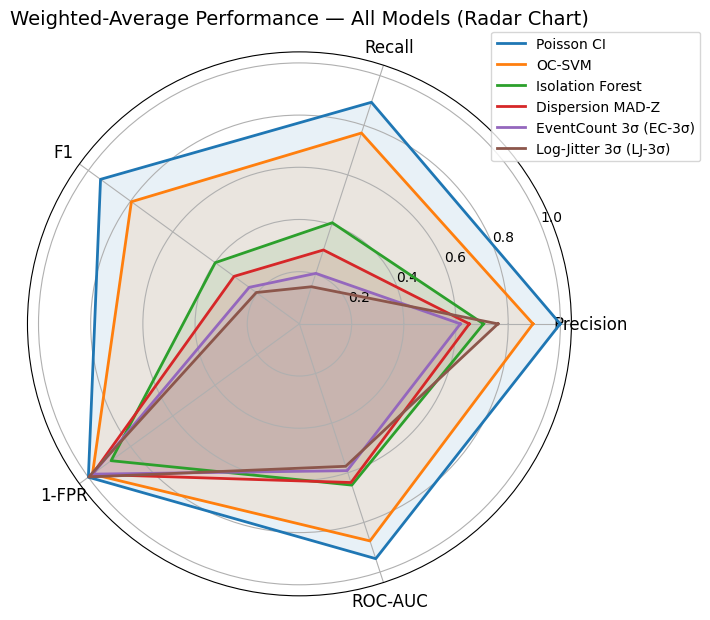

In [18]:
# ============================================================
# STEP 36: COMBINED MULTI-MODEL RADAR CHART
# ============================================================

# --- Metrics ---
metric_cols = ["Precision", "Recall", "F1", "FPR", "ROC-AUC"]

# --- Copy + adjust FPR so higher = better ---
wa_df_plot = weighted_results.copy()
wa_df_plot["FPR_adj"] = 1 - wa_df_plot["FPR"]

metric_cols_adj = ["Precision", "Recall", "F1", "FPR_adj", "ROC-AUC"]

# --- Radar angles ---
angles = np.linspace(0, 2 * np.pi, len(metric_cols_adj), endpoint=False)
angles = np.concatenate([angles, angles[:1]])

# --- Plot ---
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, polar=True)

for _, row in wa_df_plot.iterrows():
    model = row["Model"]
    values = row[metric_cols_adj].astype(float).values
    values = np.concatenate([values, values[:1]])

    ax.plot(angles, values, linewidth=2, label=model)
    ax.fill(angles, values, alpha=0.1)

# --- Labels ---
ax.set_xticks(angles[:-1])
ax.set_xticklabels(["Precision", "Recall", "F1", "1-FPR", "ROC-AUC"], fontsize=12)

ax.set_title(
    "Weighted-Average Performance — All Models (Radar Chart)",
    fontsize=14,
    pad=20
)

# --- Legend ---
plt.legend(bbox_to_anchor=(1.25, 1.05))

plt.tight_layout()

# --- Save ---
os.makedirs("../results", exist_ok=True)
plt.savefig("../results/radar_all_models.png", dpi=300)
print("[SAVED] ../results/radar_all_models.png")

plt.show()

### SUPPLEMENTARY EXPERIMENTS FOR DEEP-LEARNING BASELINES

In [19]:
# ============================================================
# SUPPLEMENTARY EXPERIMENTS (DEEP LEARNING BASELINES) 
# ============================================================

print("=" * 70)
print("SUPPLEMENTARY EXPERIMENTS FOR DEEP-LEARNING BASELINES")
print("=" * 70)
# ============================================================
# S1: LSTM AUTOENCODER
# ============================================================

class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden_dim=64, n_layers=2):
        super().__init__()
        self.encoder = nn.LSTM(n_features, hidden_dim, n_layers, batch_first=True)
        self.decoder = nn.LSTM(hidden_dim, n_features, n_layers, batch_first=True)

    def forward(self, x):
        enc_out, _ = self.encoder(x)
        dec_out, _ = self.decoder(enc_out)
        return dec_out


# ============================================================
# S2: TRANSFORMER AUTOENCODER
# ============================================================

class TransformerAE(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, n_layers=1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=128,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.decoder = nn.Linear(d_model, n_features)

    def forward(self, x):
        return self.decoder(self.encoder(self.input_proj(x)))


# ============================================================
# SEQUENCE BUILDER
# ============================================================

def create_sequences(X, window=10):
    return np.array([X[i:i+window] for i in range(len(X) - window + 1)])


# ============================================================
# DATA PREP (USE EXISTING PIPELINE DATA)
# ============================================================

n_feat = X_train.shape[1]
window_size = 10

#scaler_dl = StandardScaler()
#X_train_dl = scaler_dl.fit_transform(X_train)
#X_val_dl   = scaler_dl.transform(X_val)
X_train_dl = X_train.copy()
X_val_dl   = X_val.copy()

X_train_seq = create_sequences(X_train_dl, window_size)
X_val_seq   = create_sequences(X_val_dl, window_size)

print(f"DL setup: {len(X_train_seq)} sequences, {n_feat} features")


# ============================================================
# TRAIN LSTM AUTOENCODER
# ============================================================

torch.manual_seed(42)

lstm_ae = LSTMAutoencoder(n_features=n_feat)
optimizer_lstm = torch.optim.Adam(lstm_ae.parameters(), lr=1e-3)
criterion = nn.MSELoss()

lstm_ae.train()

for epoch in range(50):
    idx = np.random.permutation(len(X_train_seq))[:2048]
    batch = torch.FloatTensor(X_train_seq[idx])

    optimizer_lstm.zero_grad()
    loss = criterion(lstm_ae(batch), batch)
    loss.backward()
    optimizer_lstm.step()

    if (epoch+1) % 10 == 0:
        print(f"LSTM Epoch {epoch+1}/50, Loss: {loss.item():.6f}")

lstm_ae.eval()

with torch.no_grad():
    val_recon = lstm_ae(torch.FloatTensor(X_val_seq)).numpy()
    val_errors_lstm = np.mean((X_val_seq - val_recon)**2, axis=(1,2))
    lstm_threshold = np.percentile(val_errors_lstm, 95)

print(f"LSTM threshold: {lstm_threshold:.6f}")


# ============================================================
# TRAIN TRANSFORMER AUTOENCODER
# ============================================================

torch.manual_seed(42)

trans_ae = TransformerAE(n_features=n_feat)
opt_t = torch.optim.Adam(trans_ae.parameters(), lr=1e-3)

trans_ae.train()

for epoch in range(20):
    idx = np.random.permutation(len(X_train_seq))[:2048]
    batch = torch.FloatTensor(X_train_seq[idx])

    opt_t.zero_grad()
    loss = criterion(trans_ae(batch), batch)
    loss.backward()
    opt_t.step()

    if (epoch+1) % 5 == 0:
        print(f"Transformer Epoch {epoch+1}/20, Loss: {loss.item():.6f}")

trans_ae.eval()

with torch.no_grad():
    val_recon_t = trans_ae(torch.FloatTensor(X_val_seq)).numpy()
    val_errors_trans = np.mean((X_val_seq - val_recon_t)**2, axis=(1,2))
    trans_threshold = np.percentile(val_errors_trans, 95)

print(f"Transformer threshold: {trans_threshold:.6f}")


# ============================================================
# S3: COMBINED-STREAM EVALUATION (ALL ATTACKS)
# ============================================================

print("\n" + "=" * 70)
print("DL BASELINES — COMBINED-STREAM EVALUATION")
print("=" * 70)

dl_all_results = {"LSTM-AE": [], "Transformer-AE": []}

for attack_name in attack_order:

    print(f"\n--- {attack_name} ---")

    try:
        result = all_results[attack_name]

        X_attack_scaled = result["X_attack_scaled"]
        #X_attack_dl = scaler_dl.transform(X_attack_scaled)
        X_attack_dl = X_attack_scaled

        #X_attack_raw = result["X_attack_all"]
        #X_attack_dl = scaler_dl.transform(X_attack_raw)

        X_combined = np.vstack([X_val_dl, X_attack_dl])
        labels = np.concatenate([
            np.zeros(len(X_val_dl)),
            np.ones(len(X_attack_dl))
        ])

        X_comb_seq = create_sequences(X_combined, window_size)
        labels_seq = labels[window_size - 1:]

        n = min(len(X_comb_seq), len(labels_seq))
        labs = labels_seq[:n]

        for model_name, dl_model, threshold in [
            ("LSTM-AE", lstm_ae, lstm_threshold),
            ("Transformer-AE", trans_ae, trans_threshold)
        ]:

            with torch.no_grad():
                recon = dl_model(torch.FloatTensor(X_comb_seq[:n])).numpy()
                errors = np.mean((X_comb_seq[:n] - recon)**2, axis=(1,2))

            preds = (errors > threshold).astype(int)

            prec = precision_score(labs, preds, zero_division=0)
            rec  = recall_score(labs, preds, zero_division=0)
            f1   = f1_score(labs, preds, zero_division=0)
            fpr  = np.mean(preds[labs == 0]) if np.sum(labs == 0) > 0 else 0

            try:
                auc = roc_auc_score(labs, errors)
            except:
                auc = float('nan')

            n_attack_bins = int(np.sum(labs == 1))

            dl_all_results[model_name].append({
                "attack": attack_name,
                "prec": prec,
                "rec": rec,
                "f1": f1,
                "fpr": fpr,
                "auc": auc,
                "bins": n_attack_bins
            })

            print(f"{model_name}: Prec={prec:.4f} Rec={rec:.4f} F1={f1:.4f} FPR={fpr:.4f} AUC={auc:.4f}")

    except Exception as e:
        print(f"[ERROR] {attack_name}: {e}")


# ============================================================
# WEIGHTED RESULTS (DL MODELS)
# ============================================================

print("\n" + "=" * 70)
print("DL BASELINES — WEIGHTED RESULTS")
print("=" * 70)

for model_name, results_list in dl_all_results.items():

    if not results_list:
        print(f"{model_name}: No results")
        continue

    df_r = pd.DataFrame(results_list)

    w = df_r["bins"]

    w_prec = np.average(df_r["prec"], weights=w)
    w_rec  = np.average(df_r["rec"],  weights=w)
    w_f1   = np.average(df_r["f1"],   weights=w)
    w_fpr  = np.average(df_r["fpr"],  weights=w)

    valid_auc = df_r["auc"].notna()
    w_auc = np.average(df_r.loc[valid_auc, "auc"], weights=df_r.loc[valid_auc, "bins"])

    print(f"{model_name}: Prec={w_prec:.4f} Rec={w_rec:.4f} F1={w_f1:.4f} FPR={w_fpr:.6f} AUC={w_auc:.4f}")

# ============================================================
# S7: INFERENCE TIMING (FIXED — NO VARIABLE COLLISION)
# ============================================================

print("\n" + "=" * 70)
print("S7: INFERENCE TIMING (ALL METHODS)")
print("=" * 70)

# ------------------------------------------------------------
# USE EXPLICIT MODEL (DO NOT USE 'model')
# ------------------------------------------------------------
poisson_model = all_results[attack_order[0]]["poisson_model"]

# ------------------------------------------------------------
# Prepare inputs
# ------------------------------------------------------------
x1 = X_val[:1]
y1 = y_val[:1].reshape(-1, 1)

# Sequence for DL
window_size = 10
def make_one_sequence(X, window=10):
    if len(X) < window:
        pad = np.repeat(X[:1], window - len(X), axis=0)
        Xp = np.vstack([pad, X])
    else:
        Xp = X[:window]
    return Xp[np.newaxis, :, :]

x1_seq = make_one_sequence(X_val, window_size)

# ------------------------------------------------------------
# Save state
# ------------------------------------------------------------
_orig_verbose = getattr(poisson_model, "verbose", False)
_orig_lambda  = getattr(poisson_model, "lambda_estimates", None)
_orig_dual    = getattr(poisson_model, "dual_factor", None)
_orig_lpf     = getattr(poisson_model, "local_protocol_factor", 1.0)

# ------------------------------------------------------------
# Poisson-CI timing
# ------------------------------------------------------------
try:
    if _orig_lambda is not None and len(_orig_lambda) > 0:
        lam = float(_orig_lambda[0])
    else:
        lam = float(np.maximum(np.mean(y_val), 1e-6))

    poisson_model.lambda_estimates = np.array([lam])
    poisson_model.dual_factor = None
    poisson_model.local_protocol_factor = 1.0
    poisson_model.verbose = False

    # warm-up
    for _ in range(20):
        _ = poisson_model.predict_with_confidence(x1)

    t0 = time_module.perf_counter()
    for _ in range(1000):
        _ = poisson_model.predict_with_confidence(x1)

    pci_us = (time_module.perf_counter() - t0) / 1000 * 1e6

finally:
    poisson_model.verbose = _orig_verbose
    poisson_model.lambda_estimates = _orig_lambda
    poisson_model.local_protocol_factor = _orig_lpf
    if _orig_dual is not None:
        poisson_model.dual_factor = _orig_dual

# ------------------------------------------------------------
# EventCount 3σ
# ------------------------------------------------------------
mu = np.mean(y_train)
sig = np.std(y_train)

for _ in range(50):
    _ = (y1 > (mu + 3*sig)) | (y1 < (mu - 3*sig))

t0 = time_module.perf_counter()
for _ in range(10000):
    _ = (y1 > (mu + 3*sig)) | (y1 < (mu - 3*sig))

thr_us = (time_module.perf_counter() - t0) / 10000 * 1e6

# ------------------------------------------------------------
# Isolation Forest
# ------------------------------------------------------------
for _ in range(50):
    _ = iso_model.predict(x1)

t0 = time_module.perf_counter()
for _ in range(1000):
    _ = iso_model.predict(x1)

iso_us = (time_module.perf_counter() - t0) / 1000 * 1e6

# ------------------------------------------------------------
# OC-SVM
# ------------------------------------------------------------
for _ in range(50):
    _ = ocsvm.predict(x1)

t0 = time_module.perf_counter()
for _ in range(1000):
    _ = ocsvm.predict(x1)

svm_us = (time_module.perf_counter() - t0) / 1000 * 1e6

# ------------------------------------------------------------
# DL timing
# ------------------------------------------------------------
with torch.no_grad():

    # LSTM
    for _ in range(20):
        _ = lstm_ae(torch.FloatTensor(x1_seq))

    t0 = time_module.perf_counter()
    for _ in range(1000):
        _ = lstm_ae(torch.FloatTensor(x1_seq))

    lstm_us = (time_module.perf_counter() - t0) / 1000 * 1e6

    # Transformer
    for _ in range(20):
        _ = trans_ae(torch.FloatTensor(x1_seq))

    t0 = time_module.perf_counter()
    for _ in range(1000):
        _ = trans_ae(torch.FloatTensor(x1_seq))

    trans_us = (time_module.perf_counter() - t0) / 1000 * 1e6

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------
print(f"\nPoisson-CI:        {pci_us:>8.1f} us/window")
print(f"Event 3-sigma:     {thr_us:>8.1f} us/window")
print(f"Isolation Forest:  {iso_us:>8.1f} us/window")
print(f"OC-SVM:            {svm_us:>8.1f} us/window")
print(f"LSTM-AE:           {lstm_us:>8.1f} us/window")
print(f"Transformer-AE:    {trans_us:>8.1f} us/window")

SUPPLEMENTARY EXPERIMENTS FOR DEEP-LEARNING BASELINES
DL setup: 97430 sequences, 15 features


LSTM Epoch 10/50, Loss: 0.842631


LSTM Epoch 20/50, Loss: 0.820251


LSTM Epoch 30/50, Loss: 0.739655


LSTM Epoch 40/50, Loss: 0.743218


...

LSTM-AE: Prec=0.6219 Rec=0.0688 F1=0.1239 FPR=0.0500 AUC=0.4885


Transformer-AE: Prec=0.6195 Rec=0.0681 F1=0.1227 FPR=0.0500 AUC=0.4988

--- BruteForce ---


LSTM-AE: Prec=0.9822 Rec=0.9470 F1=0.9643 FPR=0.0500 AUC=0.9783


Transformer-AE: Prec=0.9820 Rec=0.9366 F1=0.9588 FPR=0.0500 AUC=0.9740

DL BASELINES — WEIGHTED RESULTS
LSTM-AE: Prec=0.9154 Rec=0.5990 F1=0.6743 FPR=0.050018 AUC=0.8700
Transformer-AE: Prec=0.9089 Rec=0.5406 F1=0.6116 FPR=0.050018 AUC=0.8363

S7: INFERENCE TIMING (ALL METHODS)



Poisson-CI:           419.3 us/window
Event 3-sigma:          1.8 us/window
Isolation Forest:    5922.7 us/window
OC-SVM:               127.3 us/window
LSTM-AE:              534.8 us/window
Transformer-AE:       221.8 us/window
